# Análise Exploratória de Dados (EDA)
## Diagnóstico de Câncer de Mama

Este notebook tem como objetivo realizar a **análise exploratória dos dados (EDA)** do *Breast Cancer Wisconsin Dataset*, que contém informações clínicas extraídas de exames de câncer de mama.

O problema abordado é de **classificação binária**, cujo objetivo é auxiliar o diagnóstico médico, identificando se um tumor é **benigno** ou **maligno**, a partir de dados estruturados.

Nesta etapa, buscamos:
1. Compreender a estrutura do dataset
2. Analisar estatísticas descritivas
3. Análise da Variável Target
4. Obter insights iniciais para as etapas de pré-processamento e modelagem

**Fonte do dataset:**  
https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data





In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


## 1. Compreensão da Estrutura do Dataset

- Número de registros e variáveis
- Tipos de dados
- Variável alvo (target)



In [3]:
# Carregar dataset
df = pd.read_csv("../data/breast_cancer_dataset.csv")


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [5]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


**Observações a partir da análise estrutural:**

- A primeira coluna (`id`) corresponde a um identificador único de cada registro. Conforme visto em aula, colunas de identificação não possuem valor preditivo e podem introduzir ruído, sendo candidatas à remoção na etapa de pré-processamento.

- A coluna `diagnosis` é a única variável categórica (`object`) e será utilizada como a variável alvo (target) do problema de classificação.

- As demais variáveis são do tipo `float64`, indicando que o dataset é composto majoritariamente por atributos numéricos contínuos.

- Observa-se a presença de 33 colunas (indexadas de 0 a 32). A última coluna, `Unnamed: 32`, não possui valores preenchidos, caracterizando um ruído do CSV, e será descartada no pré-processamento.

- Observa-se que as variáveis apresentam escalas bastante distintas, indicando a necessidade de padronização dos dados na etapa de pré-processamento.


In [6]:
df.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


**Observações a partir das estatísticas descritivas:**

- As variáveis apresentam escalas bastante distintas, reforçando a necessidade de padronização dos dados.
- Observa-se variação significativa nos desvios padrão entre as variáveis, indicando diferentes níveis de dispersão.
- Em algumas variáveis, a média e a mediana apresentam diferenças relevantes, sugerindo possível assimetria na distribuição dos dados.


### Visualização de outliers (Boxplot)

A seguir, utilizamos boxplots para visualizar possíveis valores extremos em variáveis selecionadas. Essa análise auxilia na compreensão do impacto de outliers e reforça a escolha de técnicas de escalonamento mais adequadas.

Como as variáveis possuem escalas muito diferentes, aplicamos padronização apenas para fins de visualização.


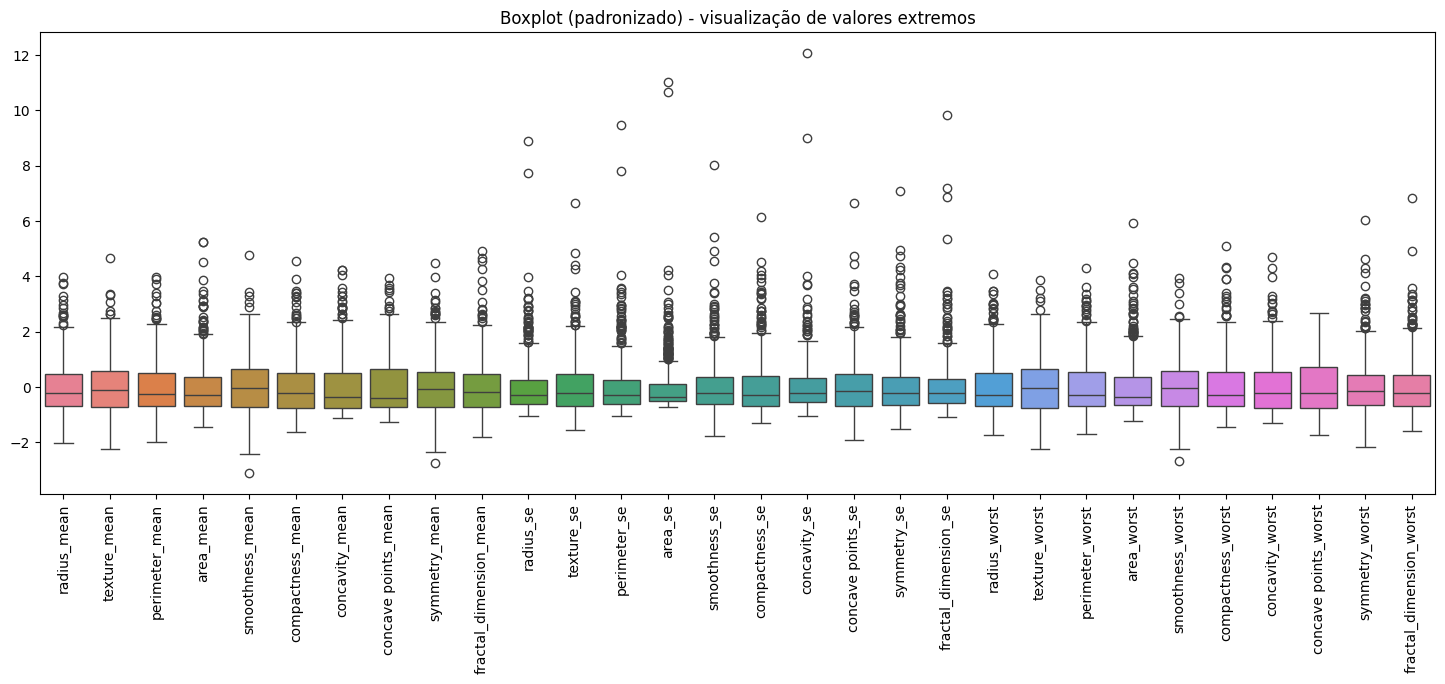

In [14]:
from sklearn.preprocessing import StandardScaler

df_num = df.drop(columns=["diagnosis", "id", "Unnamed: 32"], errors="ignore")

scaler = StandardScaler() #padronização para facilitar vizualização dos outliers
df_scaled = pd.DataFrame(
    scaler.fit_transform(df_num),
    columns=df_num.columns
)

plt.figure(figsize=(18,6))
sns.boxplot(data=df_scaled)
plt.title("Boxplot (padronizado) - visualização de valores extremos")
plt.xticks(rotation=90)
plt.show()




**Observações:**
- Observa-se a presença de valores extremos em diversas variáveis. Essa característica reforça a escolha por **padronização (StandardScaler)** na etapa de pré-processamento, já que técnicas como MinMax podem ser mais sensíveis à presença de extremos.


## 3. Análise da Variável Alvo (Target)

Nesta seção, analisamos a distribuição da variável `diagnosis`, que representa o diagnóstico do tumor (Benigno ou Maligno).


In [28]:
df["diagnosis"].value_counts()


diagnosis
B    357
M    212
Name: count, dtype: int64

In [29]:

df["diagnosis"].value_counts(normalize=True) * 100

diagnosis
B    62.741652
M    37.258348
Name: proportion, dtype: float64

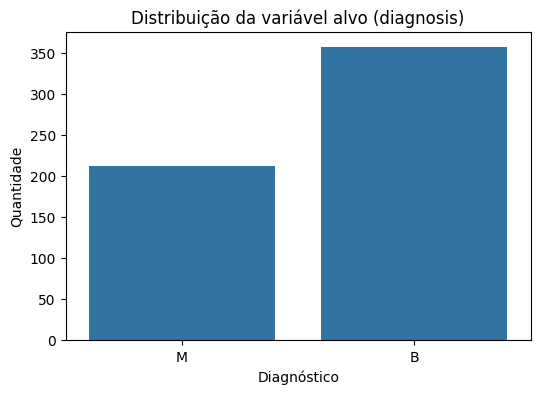

In [22]:
plt.figure(figsize=(6,4))
sns.countplot(x="diagnosis", data=df)
plt.title("Distribuição da variável alvo (diagnosis)")
plt.xlabel("Diagnóstico")
plt.ylabel("Quantidade")
plt.show()




**Observações da variável target:**
    
- A variável `diagnosis` apresenta apenas duas classes (`B` e `M`), caracterizando um problema de **classificação binária**. 

- Observa-se maior quantidade de casos **benignos (B)** em relação aos **malignos (M)**, indicando **leve desbalanceamento** entre as classes. Esse aspecto deverá ser considerado durante a etapa de treinamento e avaliação dos modelos.

- Por se tratar de um contexto médico, erros do tipo **falso negativo** podem ter impacto relevante. Dessa forma, além da acurácia, serão consideradas métricas de avaliação que levem em conta esse cenário, como **Recall** e **F1-score**.


## 4. Análise de Correlação entre Variáveis

Nesta etapa, analisamos a correlação entre as variáveis numéricas para identificar relações fortes (redundância de informação), o que pode impactar a modelagem.



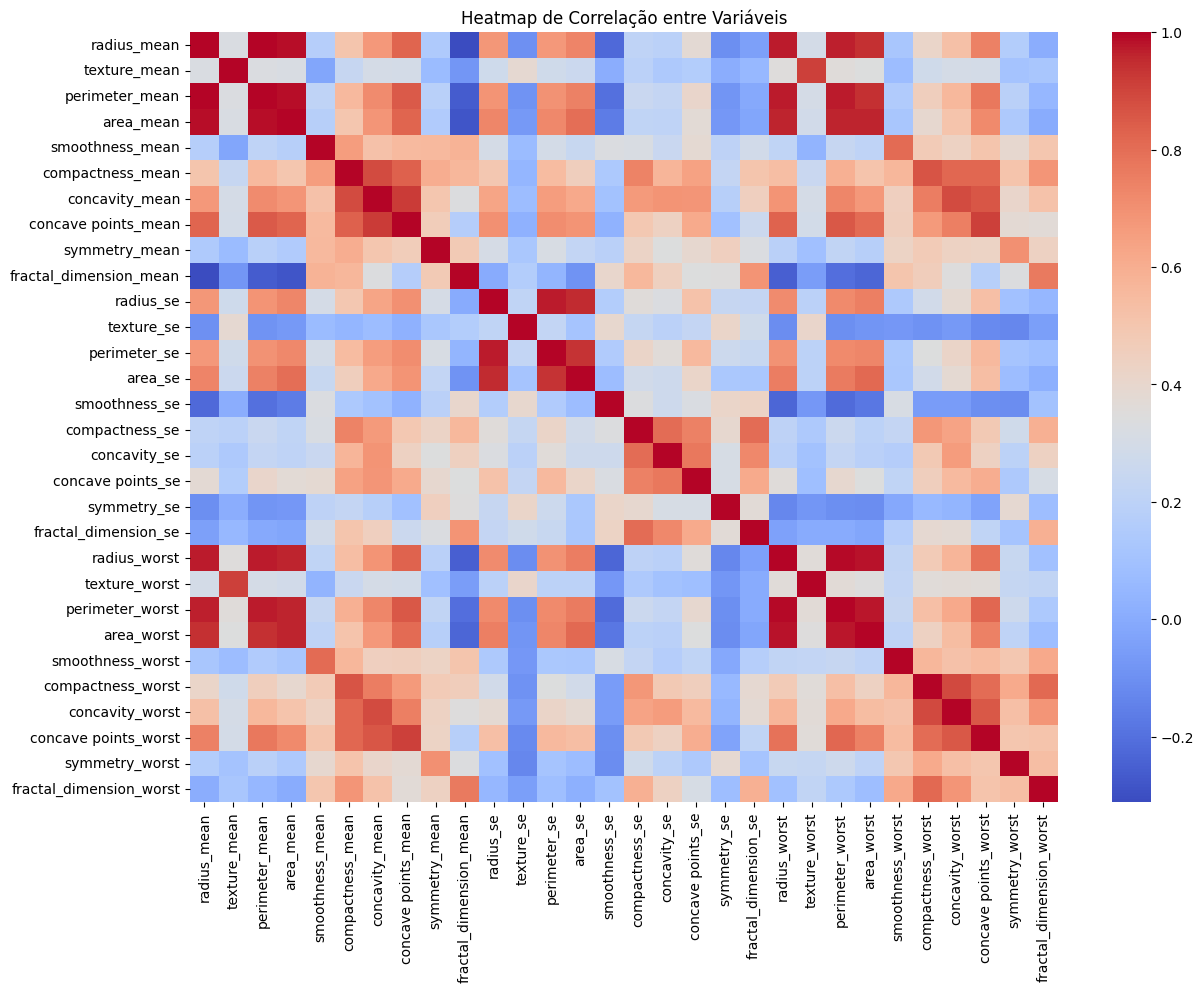

In [33]:
# Correlação (removendo colunas irrelevantes)
df_corr = df.drop(columns=["id", "Unnamed: 32"], errors="ignore")

corr = df_corr.drop(columns=["diagnosis"], errors="ignore").corr()

plt.figure(figsize=(14,10))
sns.heatmap(corr, cmap="coolwarm")
plt.title("Heatmap de Correlação entre Variáveis")
plt.show()


**Observações:**
- - Observa-se **alta correlação** entre algumas variáveis, principalmente entre medidas relacionadas ao tamanho do tumor, como `radius`, `perimeter` e `area` (tanto nas versões `mean` quanto `worst`), indicando **redundância de informação**.
- Em etapas futuras (pré-processamento/modelagem), pode-se considerar PCA como técnica de redução de dimensionalidade.


## Conclusão da Análise Exploratória (EDA)

Com base nas análises realizadas, foi possível obter os seguintes pontos principais:

- O dataset possui estrutura adequada para o problema proposto, contendo variáveis majoritariamente numéricas (`float64`) e uma variável alvo categórica (`diagnosis`), caracterizando um problema de **classificação binária**.

- Foram identificadas colunas que não agregam valor ao modelo:
  - `id` (identificador)
  - `Unnamed: 32` (coluna vazia)
  Essas colunas serão removidas na etapa de pré-processamento.

- As estatísticas descritivas indicaram que as variáveis apresentam **escalas bastante distintas** E **OUTLIERS**, reforçando a necessidade de aplicação de **padronização** (feature scaling) antes do treinamento de modelos.

- A distribuição da variável alvo mostrou **leve desbalanceamento** entre as classes, o que deverá ser considerado na etapa de treinamento e avaliação.

- A matriz de correlação mostrou grupos de variáveis fortemente correlacionadas (ex.: `radius`, `perimeter` e `area`), sugerindo **redundância** e possível **multicolinearidade**.